In [201]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *

In [202]:
data_path = "result/trace_csv"

raw_data_path = os.path.join(data_path, "raw")
t_dwell_path = os.path.join(data_path, "t_dwell")

# Scan data that ends with .csv
raw_data_files = [f.path for f in os.scandir(raw_data_path) if f.is_file() and f.name.endswith('.csv')]
t_dwell_files = [f.path for f in os.scandir(t_dwell_path) if f.is_file() and f.name.endswith('.csv')]
raw_data_files.sort()
t_dwell_files.sort()

print(f"Found {len(raw_data_files)} raw data files and {len(t_dwell_files)} t_dwell files.")
i = 0
for raw_file in raw_data_files:
    print(f"    {i}: {raw_file.split('/')[-1].split('.')[0]}")
    i += 1

Found 10 raw data files and 10 t_dwell files.
    0: FL_2x_4EGI1
    1: FL_2x_CHX
    2: FL_2x_Har
    3: FL_2x_puro
    4: FLmRNA_1x
    5: FLmRNA_2x
    6: THOR_1x
    7: THOR_2x
    8: THORdel_2x
    9: THORdelta_1x


In [203]:
index = 5

target_raw_file = raw_data_files[index]
target_t_dwell_file = t_dwell_files[index]
print(f"Processing raw data file: {target_raw_file}")

Processing raw data file: result/trace_csv/raw/FLmRNA_2x.csv


In [204]:
data_df = pd.read_csv(target_raw_file)
t_dwell_df = pd.read_csv(target_t_dwell_file)

In [205]:
data_df

,experiment,trackID,t,distance_um,contour_area,contour_coords
0,20220508-FLmRNA_2x_FOV,6,0.0,-0.032633,22.0,POINT (91.6590909090909 247.25)
1,20220508-FLmRNA_2x_FOV,6,0.1,-0.008804,22.5,POINT (91.17037037037038 247.02962962962965)
2,20220508-FLmRNA_2x_FOV,6,0.2,-0.030452,20.0,POINT (91.38333333333334 247.31666666666666)
3,20220508-FLmRNA_2x_FOV,6,0.3,-0.007836,21.5,POINT (91.42635658914729 247.15503875968992)
4,20220508-FLmRNA_2x_FOV,6,0.4,-0.122833,23.0,POINT (91.5 247.24637681159422)
...,...,...,...,...,...,...
415816,20220508-FLmRNA_2x_FOV-9,4701,18.3,-0.035975,17.0,POINT (201.2843137254902 298.2254901960784)
415817,20220508-FLmRNA_2x_FOV-9,4701,18.4,-0.109002,20.0,POINT (201 298.3)
415818,20220508-FLmRNA_2x_FOV-9,4701,18.5,-0.092475,14.0,POINT (201.21428571428572 298.1547619047619)
415819,20220508-FLmRNA_2x_FOV-9,4701,18.6,-0.121428,13.5,POINT (201.2469135802469 298.2716049382716)


In [206]:
unique_experiments = data_df['experiment'].unique()
unique_experiments

array(['20220508-FLmRNA_2x_FOV', '20220508-FLmRNA_2x_FOV-1',
       '20220508-FLmRNA_2x_FOV-10', '20220508-FLmRNA_2x_FOV-11',
       '20220508-FLmRNA_2x_FOV-12', '20220508-FLmRNA_2x_FOV-13',
       '20220508-FLmRNA_2x_FOV-14', '20220508-FLmRNA_2x_FOV-15',
       '20220508-FLmRNA_2x_FOV-16', '20220508-FLmRNA_2x_FOV-17',
       '20220508-FLmRNA_2x_FOV-18', '20220508-FLmRNA_2x_FOV-19',
       '20220508-FLmRNA_2x_FOV-2', '20220508-FLmRNA_2x_FOV-20',
       '20220508-FLmRNA_2x_FOV-21', '20220508-FLmRNA_2x_FOV-22',
       '20220508-FLmRNA_2x_FOV-23', '20220508-FLmRNA_2x_FOV-24',
       '20220508-FLmRNA_2x_FOV-25', '20220508-FLmRNA_2x_FOV-3',
       '20220508-FLmRNA_2x_FOV-4', '20220508-FLmRNA_2x_FOV-5',
       '20220508-FLmRNA_2x_FOV-6', '20220508-FLmRNA_2x_FOV-7',
       '20220508-FLmRNA_2x_FOV-8', '20220508-FLmRNA_2x_FOV-9'],
      dtype=object)

In [207]:
experiment = "20220508-FLmRNA_2x_FOV-17"

filtered_df = data_df[data_df['experiment'] == experiment]
filtered_df

,experiment,trackID,t,distance_um,contour_area,contour_coords
129610,20220508-FLmRNA_2x_FOV-17,0,10.0,-0.040495,14.5,POINT (7.942528735632184 606.0574712643679)
129611,20220508-FLmRNA_2x_FOV-17,0,10.1,0.063866,14.5,POINT (7.942528735632184 605.9425287356321)
129612,20220508-FLmRNA_2x_FOV-17,0,10.2,0.064022,14.0,POINT (8 606)
129613,20220508-FLmRNA_2x_FOV-17,0,10.3,0.064412,14.0,POINT (8 606)
129614,20220508-FLmRNA_2x_FOV-17,0,10.4,0.072279,14.0,POINT (8 606)
...,...,...,...,...,...,...
146331,20220508-FLmRNA_2x_FOV-17,3946,17.5,-0.072329,130.0,POINT (292.2423076923077 413.6679487179487)
146332,20220508-FLmRNA_2x_FOV-17,3946,17.7,-0.055052,133.0,POINT (292.20426065162906 413.7706766917293)
146333,20220508-FLmRNA_2x_FOV-17,3946,17.8,-0.143806,132.5,POINT (292.2691823899371 413.7320754716981)
146334,20220508-FLmRNA_2x_FOV-17,3946,17.9,0.322350,129.0,POINT (292.3423772609819 413.6782945736434)


In [208]:
track_id_list = filtered_df['trackID'].unique()
track_id_list.sort()
track_id_list

array([   0,   18,   20,   21,   22,   26,   27,   33,   34,   35,   38,
         39,   42,   55,   61,   62,   65,   72,   96,  102,  103,  104,
        111,  126,  128,  139,  158,  163,  167,  168,  187,  191,  197,
        198,  201,  207,  210,  211,  213,  218,  224,  227,  229,  230,
        231,  238,  240,  242,  244,  254,  261,  273,  283,  298,  303,
        309,  316,  322,  325,  326,  331,  332,  343,  345,  367,  368,
        369,  371,  375,  379,  381,  384,  386,  390,  393,  397,  403,
        405,  409,  411,  412,  416,  424,  429,  431,  434,  436,  440,
        443,  446,  449,  450,  451,  452,  456,  461,  462,  465,  485,
        489,  490,  492,  493,  494,  497,  502,  510,  511,  514,  522,
        528,  540,  547,  563,  565,  571,  582,  584,  588,  596,  597,
        602,  616,  618,  628,  639,  701,  717,  718,  720,  724,  743,
        747,  749,  764,  769,  781,  790,  797,  799,  803,  806,  865,
        876,  882,  884,  892,  893, 1009, 1013, 10

In [209]:
from shapely import wkt

def parse_contour_coords(coord_str):
    """
    Parses a WKT string representation of a point or a list of points.
    """
    if pd.isna(coord_str):
        return None
    return wkt.loads(coord_str)

In [210]:
from shapely.geometry import Point

norm_contour_area_list = []
std_contour_area_list = []
coords_list = []
frames_list = []

for track_id in track_id_list:
    df = filtered_df[filtered_df['trackID'] == track_id]
    temp_t_dwell_df = t_dwell_df[(t_dwell_df['experiment'] == experiment) & (t_dwell_df['trackID'] == track_id)].iloc[0]
    
    t_dwell = temp_t_dwell_df['t_dwell']
    df = df[df['t'] >= t_dwell]

    coords = [parse_contour_coords(xy) for xy in df['contour_coords']]
    
    contour_area = df['contour_area'].values
    
    norm_contour_area = contour_area / np.median(contour_area)
    norm_contour_area_list.append(norm_contour_area)
    std_contour_area_list.append(np.std(norm_contour_area))
    coords_list.append(coords)
    frames_list.append(df['t'].values)

exp_df = pd.DataFrame({
    'trackID': track_id_list,
    'norm_contour_area': norm_contour_area_list,
    'std_contour_area': std_contour_area_list,
    'coords': coords_list,
    'frames_list': frames_list
})

# Flatten the list
all_norm_contour_area = np.concatenate(norm_contour_area_list)
all_std_contour_area = np.array(std_contour_area_list)

In [211]:
exp_df

,trackID,norm_contour_area,std_contour_area,coords,frames_list
0,0,"[1.0, 1.0, 0.9655172413793104, 0.9655172413793...",0.069229,"[POINT (7.942528735632184 606.0574712643679), ...","[10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10...."
1,18,"[1.0743801652892562, 1.0413223140495869, 1.008...",0.053868,"[POINT (55.68205128205128 606.425641025641), P...","[0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000001, ..."
2,20,"[1.05, 1.1, 0.9833333333333333, 1.016666666666...",0.051955,"[POINT (55.560846560846564 606.3756613756614),...","[4.6000000000000005, 4.7, 4.800000000000001, 4..."
3,21,"[1.1428571428571428, 0.9523809523809523, 1.047...",0.081977,"[POINT (134.34027777777777 570.6666666666666),...","[7.300000000000001, 7.4, 7.5, 7.6, 7.7, 7.8000..."
4,22,"[1.0, 1.0277777777777777, 1.0555555555555556, ...",0.137649,"[POINT (133.27777777777777 571.6111111111111),...","[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6000000000000..."
...,...,...,...,...,...
311,3825,"[1.0, 0.992831541218638, 1.010752688172043, 1....",0.008298,[POINT (292.52329749103944 413.77658303464756)...,"[18.8, 18.9, 19.0, 19.1, 19.200000000000003]"
312,3851,"[0.9069767441860465, 1.0232558139534884, 1.069...",0.088045,"[POINT (133.84615384615384 571.5470085470085),...","[18.0, 18.1, 18.2, 18.4, 18.5, 18.6, 18.8, 18...."
313,3916,"[0.9487179487179487, 1.0, 0.8974358974358975, ...",0.044105,"[POINT (397.44144144144144 93.95495495495496),...","[18.9, 19.0, 19.1, 19.200000000000003, 19.3, 1..."
314,3920,"[0.9230769230769231, 1.0153846153846153, 1.107...",0.070232,"[POINT (17 102), POINT (17.11111111111111 102....","[19.0, 19.1, 19.200000000000003, 19.3, 19.4, 1..."


In [212]:
df['contour_coords'].values[0]

'POINT (292.43023255813955 413.76356589147287)'

Max step size
X: 1.12
Y: 7.28
Modal value: 1.00, Count: 7
The data is not normally distributed (reject H0), p-value: 5.180231707214352e-07


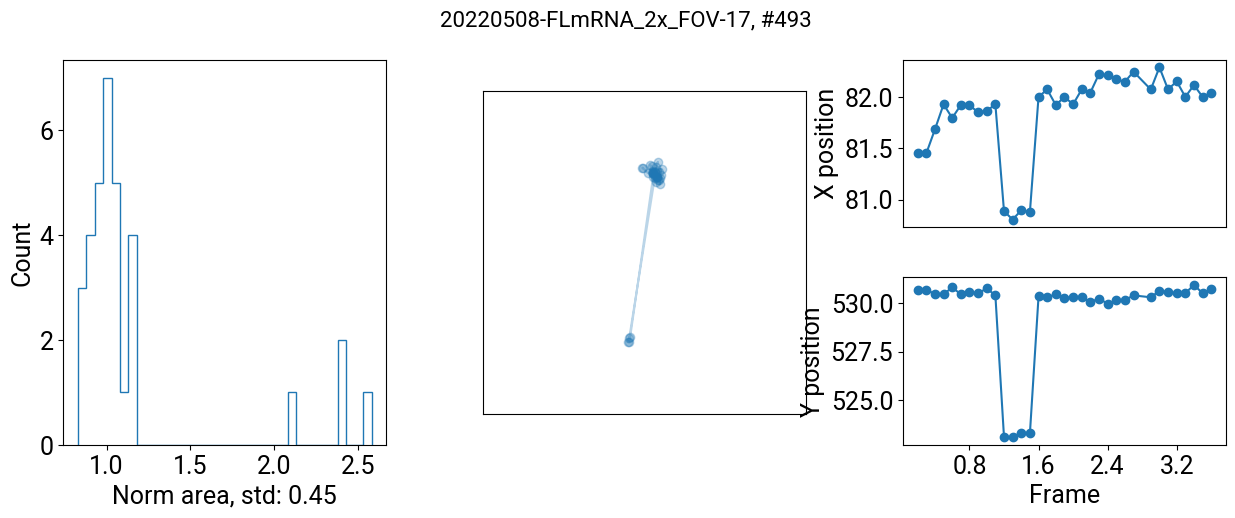

In [245]:
check_idx = 102
norm_contour_area = np.array(norm_contour_area_list[check_idx])
std_contour_area = std_contour_area_list[check_idx]
track_id = track_id_list[check_idx]

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1], wspace=0.3, hspace=0.3)

# ax[0] - Histogram
ax0 = fig.add_subplot(gs[:, 0])
bin_width = 0.05
ax0.hist(norm_contour_area, bins=np.arange(np.round(np.min(norm_contour_area), 2), np.round(np.max(norm_contour_area), 2) + bin_width, bin_width), histtype='step', density=False)
ax0.set_xlabel(f"Norm area, std: {std_contour_area:.2f}")
ax0.set_ylabel("Count")

# ax[1] - Trajectory
ax1 = fig.add_subplot(gs[:, 1])
coords = coords_list[check_idx]
x_vals = [point.x for point in coords if point is not None]
y_vals = [point.y for point in coords if point is not None]

x_max_step_size = np.max(np.abs(np.diff(x_vals)))
y_max_step_size = np.max(np.abs(np.diff(y_vals)))
print(f"Max step size\nX: {x_max_step_size:.2f}\nY: {y_max_step_size:.2f}")


ax1.plot(x_vals, y_vals, marker='o', linestyle='-', alpha=0.3)

x_length = int(np.max(x_vals) - np.min(x_vals))
y_length = int(np.max(y_vals) - np.min(y_vals))
center_x = (np.max(x_vals) + np.min(x_vals)) / 2
center_y = (np.max(y_vals) + np.min(y_vals)) / 2

window_size = max(x_length, y_length, 1)
box_length = window_size * 2

ax1.set_xlim(center_x - 0.5 * box_length, center_x + 0.5 * box_length)
ax1.set_ylim(center_y - 0.5 * box_length, center_y + 0.5 * box_length)
ax1.set_aspect('equal', adjustable='box')
ax1.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

from scipy.stats import mode
modal_value, count = mode(norm_contour_area)
print(f"Modal value: {modal_value:.2f}, Count: {count}")

# Normality check
from scipy.stats import normaltest

if len(norm_contour_area) > 20:
    stat, p = normaltest(norm_contour_area)
    alpha = 0.05
    if p < alpha:
        print(f"The data is not normally distributed (reject H0), p-value: {p}")
    else:
        print("The data is normally distributed (fail to reject H0)")
else:
    print("Not enough data points to perform normality test.")

# Right-side plots
ax2_top = fig.add_subplot(gs[0, 2])
ax2_bottom = fig.add_subplot(gs[1, 2])

# ax[2] top: x vs frame
frames = exp_df.loc[check_idx, 'frames_list']
ax2_top.plot(frames, x_vals, marker='o', linestyle='-')
ax2_top.set_ylabel("X position")
ax2_top.tick_params(bottom=False, labelbottom=False)
ax2_top.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

# ax[2] bottom: y vs frame
ax2_bottom.plot(frames, y_vals, marker='o', linestyle='-')
ax2_bottom.set_xlabel("Frame")
ax2_bottom.set_ylabel("Y position")
ax2_bottom.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
ax2_bottom.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

plt.suptitle(f"{experiment}, #{track_id}", fontsize=16)

output_dir = 'result/filtering_img'
plt.savefig(os.path.join(output_dir, f"{experiment}_{track_id}.png"), bbox_inches='tight')

plt.show()

Number of tracks with outliers: 93 out of 316 (29.43%)


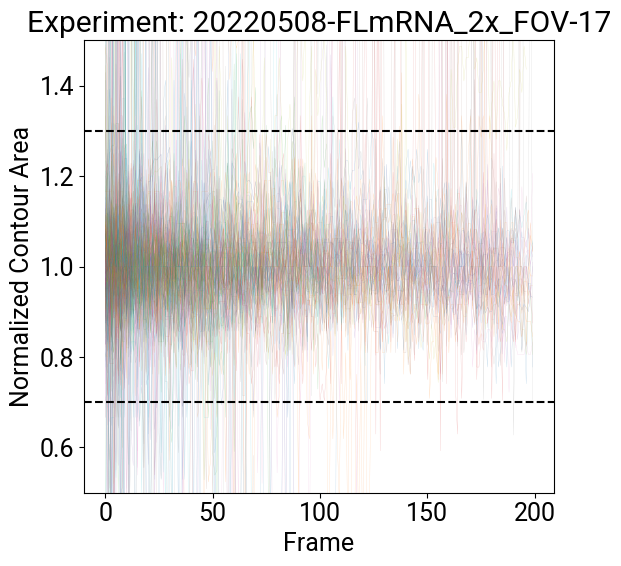

In [214]:
fig, ax = plt.subplots(figsize=(6,6))
count = 0
for norm_contour_area in norm_contour_area_list:
    ax.plot(np.arange(len(norm_contour_area)), norm_contour_area, alpha=0.3, lw=0.2)
    if np.max(norm_contour_area) > 1.3 or np.min(norm_contour_area) < 0.7:
        count += 1
    ax.set_xlabel("Frame")
    ax.set_ylabel("Normalized Contour Area")
    ax.set_title(f"Experiment: {experiment}")    
     
ax.axhline(1.3, color='black', linestyle='--', label='Upper threshold (1.3)')
ax.axhline(0.7, color='black', linestyle='--', label='Lower threshold (0.7)')

ax.set_ylim(0.5, 1.5)

plt.tight_layout()
print(f"Number of tracks with outliers: {count} out of {len(track_id_list)} ({count/len(track_id_list)*100:.2f}%)")

In [215]:
temp_t_dwell_df

experiment                            20220508-FLmRNA_2x_FOV-17
trackID                                                    3946
contour_area                                              129.0
contour_coords    POINT (292.43023255813955 413.76356589147287)
t_dwell                                                    17.4
Name: 116581, dtype: object

In [216]:
df

,experiment,trackID,t,distance_um,contour_area,contour_coords
146330,20220508-FLmRNA_2x_FOV-17,3946,17.4,-0.038846,129.0,POINT (292.43023255813955 413.76356589147287)
146331,20220508-FLmRNA_2x_FOV-17,3946,17.5,-0.072329,130.0,POINT (292.2423076923077 413.6679487179487)
146332,20220508-FLmRNA_2x_FOV-17,3946,17.7,-0.055052,133.0,POINT (292.20426065162906 413.7706766917293)
146333,20220508-FLmRNA_2x_FOV-17,3946,17.8,-0.143806,132.5,POINT (292.2691823899371 413.7320754716981)
146334,20220508-FLmRNA_2x_FOV-17,3946,17.9,0.322350,129.0,POINT (292.3423772609819 413.6782945736434)
146335,20220508-FLmRNA_2x_FOV-17,3946,18.0,-0.161393,131.5,POINT (292.2294043092522 413.7515842839037)


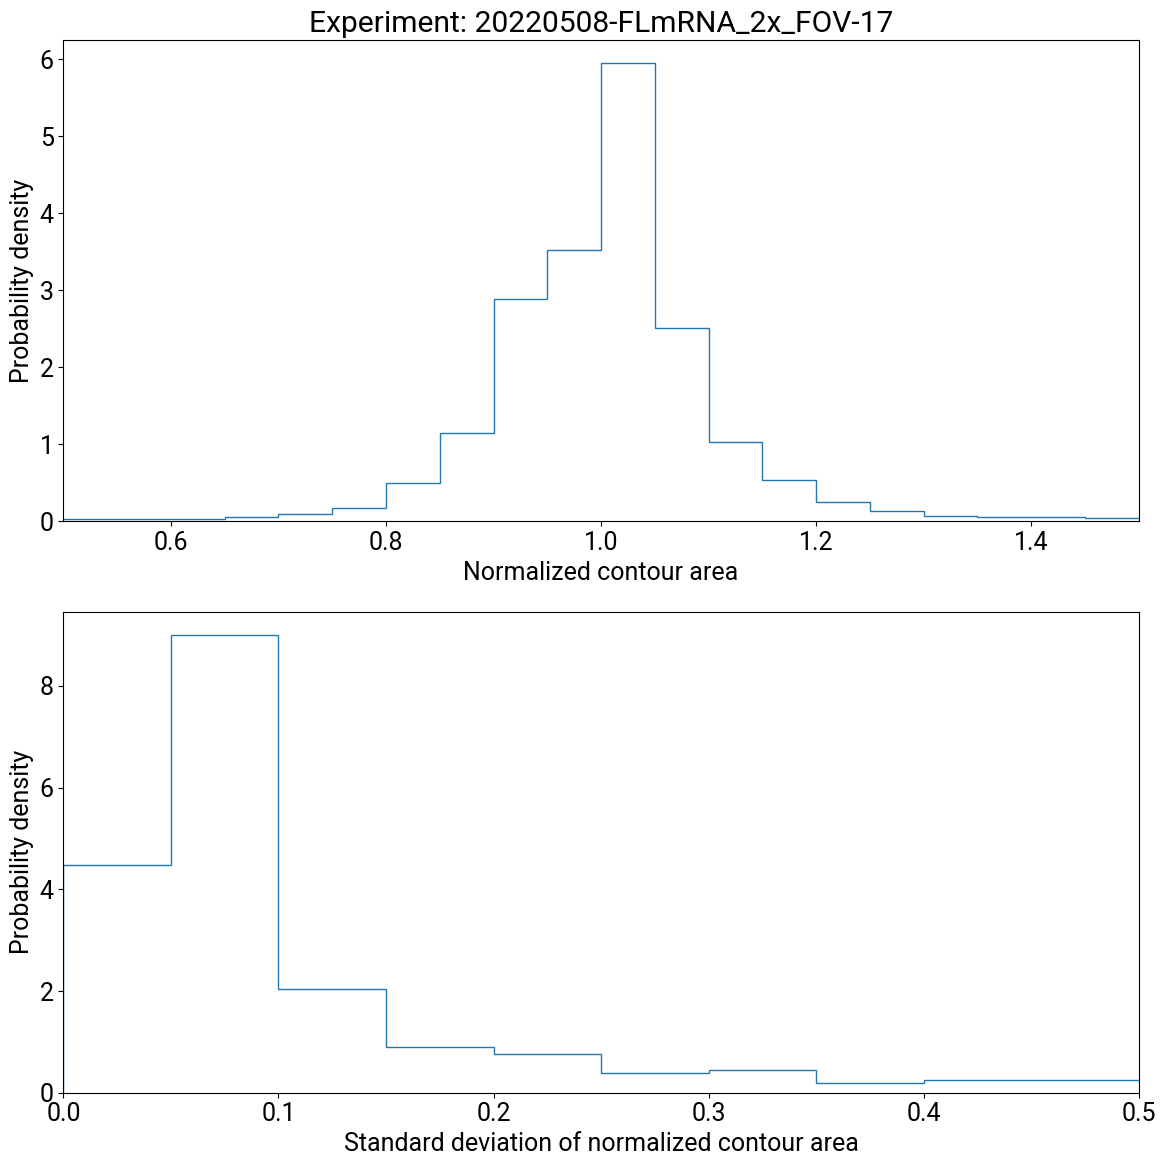

In [217]:
fig, ax = plt.subplots(2, 1, figsize=(12,12))
bin_width = 0.05

ax[0].hist(all_norm_contour_area, bins=np.arange(0, 6 + bin_width, bin_width), histtype='step', density=True)

ax[0].set_xlabel("Normalized contour area")
ax[0].set_ylabel("Probability density")
ax[0].set_title(f"Experiment: {experiment}")
ax[0].set_xlim(0.5, 1.5)

ax[1].hist(all_std_contour_area, bins=np.arange(0, 6 + bin_width, bin_width), histtype='step', density=True)
ax[1].set_xlabel("Standard deviation of normalized contour area")
ax[1].set_ylabel("Probability density")
ax[1].set_xlim(0, 0.5)

fig.tight_layout()